* Gold, Oil, and Geopolitical Risk (GPR) Analysis
This project investigates the relationship between gold prices, Brent oil prices, and the Geopolitical Risk Index (GPRD) between 2000 and 2026.

Objective: To perform exploratory data analysis and hypothesis testing to determine if there is a statistically meaningful correlation between these commodities and global risks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


* Data Collection and Preprocessing
 Since investing.com did not give full data between 2000-2026 due to a technical problem, I get the data as 2 parts and I concatenated them.


 First gold data (2000-2020):


In [2]:
df_gold1 = pd.read_csv('Gold Futures Historical Data (3).csv')


 Second gold data (2020-2026):


In [3]:
df_gold2 = pd.read_csv('Gold Futures Historical Data (4).csv')


Concatenated data:

In [4]:
df_gold = pd.concat([df_gold1, df_gold2], axis=0)
df_gold['Date'] = pd.to_datetime(df_gold['Date'])

 Sorting the dates and dropping duplicating dates:

In [5]:
df_gold = df_gold.sort_values(by='Date',ascending=False)
df_gold = df_gold.drop_duplicates()


 As I do for gold data, I also get the oil data as 2 parts and concatenated them:

In [6]:
oil1 = pd.read_csv('Brent Oil Futures Historical Data (1).csv', thousands=',', decimal='.')
oil2 = pd.read_csv('Brent Oil Futures Historical Data.csv', thousands=',', decimal='.')

df_oil = pd.concat([oil1, oil2], axis=0)
df_oil['Date'] = pd.to_datetime(df_oil['Date'])
df_oil = df_oil.sort_values(by='Date', ascending=False).drop_duplicates()


Reading GPR data. I filter the dates between 2000-2026. Also, column names were different than gold and oil data so I fixed it:

In [7]:
df_gpr = pd.read_csv('data_gpr_daily_recent.csv')
df_gpr['date'] = pd.to_datetime(df_gpr['date'])

df_gpr = df_gpr[df_gpr['date'] >= '2000-01-01']
df_gpr = df_gpr.rename(columns={'date': 'Date'})


 I merged the Gold and Oil data with the dates in which they intersect using "how='inner'"":

In [8]:
df_GoldandOil = pd.merge(df_gold, df_oil, on='Date', how='inner')


Then merged all of the three data:

In [9]:
df_final = pd.merge(df_GoldandOil, df_gpr, on='Date', how='inner')


Let's check how the data looks using .head()

In [14]:
print(df_final.head())

df_final.to_csv('gold_oil_gpr_merged.csv', index=False)


        Date Gold_Price    Open_x    High_x     Low_x   Vol._x Change %_x  \
0 2026-04-13   4,734.30  4,693.65  4,766.62  4,686.80   89.06K      0.87%   
1 2026-04-12   4,693.30  4,709.50  4,713.65  4,626.00      NaN     -1.97%   
2 2026-04-10   4,787.40  4,790.50  4,820.00  4,752.70  121.57K     -0.64%   
3 2026-04-09   4,818.00  4,744.80  4,826.00  4,718.60  133.63K      0.85%   
4 2026-04-08   4,777.20  4,747.20  4,888.00  4,720.60  215.12K      1.97%   

   Oil_Price  Open_y  High_y  ...       DAY N10D    GPRD  GPRD_ACT  \
0     101.88  103.06  103.49  ...  20260413  294  304.22    494.23   
1     103.11  102.50  103.88  ...  20260412  312  169.88    211.69   
2      95.20   96.60   98.26  ...  20260410  533  329.39    359.36   
3      95.92   97.10   99.50  ...  20260409  489  413.22    526.76   
4      94.75   95.00   97.22  ...  20260408  483  294.91    478.60   

   GPRD_THREAT GPRD_MA30 GPRD_MA7  event  var_name  var_label  
0       393.50    292.76   292.47    NaN       NaN  

Making column names more readable:

In [12]:
df_final = df_final.rename(columns={'Price_x': 'Gold_Price', 'Price_y': 'Oil_Price'})

 Checking the statistical features such as mean, std and quartiles using .describe():

In [15]:
print(df_final[['Gold_Price', 'Oil_Price', 'GPRD']].describe())

         Oil_Price
count  6248.000000
mean     67.038856
std      28.428025
min      17.680000
25%      45.130000
50%      65.780000
75%      85.150000
max     146.080000


Calculating the Pearson and Spearman correlations, 

Cleaning the comma and percentage signs in numbers and convert them to float:

In [16]:
for col in ['Gold_Price', 'Oil_Price', 'GPRD', 'Change %_x', 'Change %_y','GPRD_ACT', 'GPRD_THREAT', 'GPRD_MA7', 'GPRD_MA30']:
    if col in df_final.columns:
        
        df_final[col] = (df_final[col].astype(str).str.replace('%', '').str.replace(',', '').str.strip())
        
        
        df_final[col] = pd.to_numeric(df_final[col], errors='coerce')

df_final = df_final.dropna(subset=['Gold_Price', 'Oil_Price', 'GPRD', 'Change %_x', 'Change %_y','GPRD_ACT', 'GPRD_THREAT', 'GPRD_MA7', 'GPRD_MA30'])


Calculating the Pearson and Spearman correlation between gold and oil prices:

In [17]:
pearson_val = df_final["Gold_Price"].corr(df_final["Oil_Price"], method='pearson')
spearman_val = df_final["Gold_Price"].corr(df_final["Oil_Price"], method='spearman')


Checking the correlation values and sketching the graph:

Pearson Correlation: 0.4377
Spearman Correlation: 0.6012


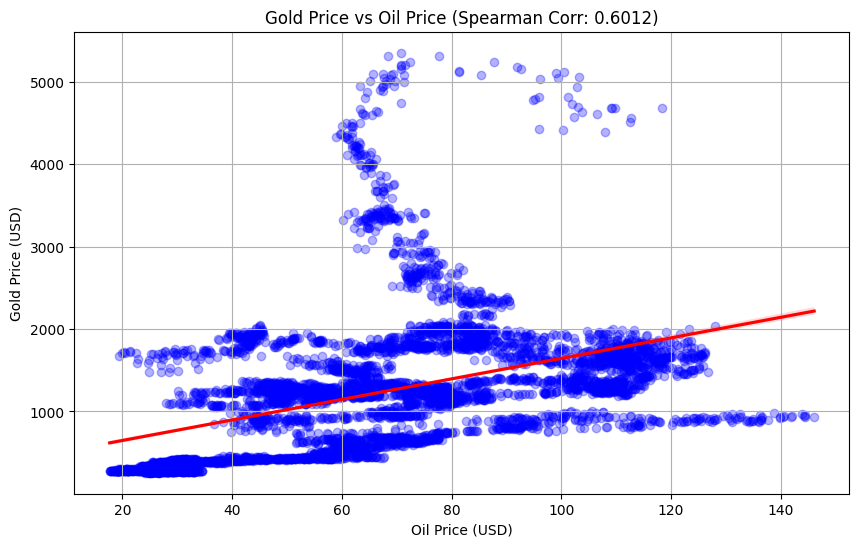

In [ ]:
print(f"Pearson Correlation: {pearson_val:.4f}")
print(f"Spearman Correlation: {spearman_val:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='Oil_Price', y='Gold_Price', data=df_final, scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
plt.title(f'Gold Price vs Oil Price (Spearman Corr: {spearman_val:.4f})')
plt.xlabel('Oil Price (USD)')
plt.ylabel('Gold Price (USD)')
plt.grid(True)

plt.show()

HYPOTHESIS TESTING:
Spearman correlation is 0.6012. I costruct hypotesis testing to reflect whether this is a coincedence or there is a meaningful correlation.
* Null Hypothesis H0 = "There is no correlation between Gold and Oil Prices."
* Alternative Hypothesis HA= "There is a considirable correlation between Oil and Gold prices."

Initially, I set alpha value to 0.05. If p value is less then 0.05, we can reject H0 and conclude that there is a meaningful correlation.


In [20]:
alpha = 0.05
spearman, p_value = stats.spearmanr(df_final['Gold_Price'], df_final['Oil_Price'])
if (p_value < alpha):
    print(f"p value: {p_value:.10e}")
    print("p value is smaller than alpha, Null Hypothesis H0 is rejected.")
    print("There is a statistically meaningful correlation between gold and oil prices.")


p value: 0.0000000000e+00
p value is smaller than alpha, Null Hypothesis H0 is rejected.
There is a statistically meaningful correlation between gold and oil prices.


I reach the p value is less then 0.00001 and conclude that there is a strong correlation between gold and oil prices. 

And same proccess to inspect the correlation between oil prices and GPR index:

In [21]:
spearman, p_value = stats.spearmanr(df_final['Oil_Price'], df_final['GPRD'])

if (p_value < alpha):
    print(f"p value: {p_value:.10e}")
    print("p value is smaller than alpha, Null Hypothesis H0 is rejected.")
    print("There is a statistically meaningful correlation between oil prices and GPR index.")

p value: 5.3021815704e-06
p value is smaller than alpha, Null Hypothesis H0 is rejected.
There is a statistically meaningful correlation between oil prices and GPR index.


p value for correlation between such commodities and GPR index resulted in that "Gold and Oil prices meaningfully correlated with GPR index."
